In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


SECTION 1: DATASET OVERVIEW

Dataset Shape: (98, 5)

Columns: ['participant_id', 'source_identity', 'attack_type', 'file_path', 'label']

First 5 Rows:


,participant_id,source_identity,attack_type,file_path,label
0,P001,P003,impersonation,/content/drive/MyDrive/Final Dataset/Sam - fin...,1
1,P003,P004,impersonation,/content/drive/MyDrive/Final Dataset/Sam - fin...,1
2,P004,P006,impersonation,/content/drive/MyDrive/Final Dataset/Sam - fin...,1
3,P006,P007,impersonation,/content/drive/MyDrive/Final Dataset/Sam - fin...,1
4,P007,P008,impersonation,/content/drive/MyDrive/Final Dataset/Sam - fin...,1



Unique attack types: ['impersonation']
Unique labels: [1]

SECTION 2: INTEGRITY CHECKS

Missing Values:
participant_id     0
source_identity    0
attack_type        0
file_path          0
label              0
dtype: int64

Duplicate Rows: 0
Duplicate File Paths: 0

Invalid attack_type rows: 0
Invalid label rows: 0

Missing Files: 98

SECTION 3: IDENTITY LOGIC VALIDATION

Same Identity (INVALID for impersonation): 0
Valid Impersonation Samples: 98

SECTION 4: VIDEO VALIDATION

Corrupted Videos: 0

SECTION 5: DISTRIBUTION ANALYSIS

Top Attackers:
participant_id
P001    1
P003    1
P004    1
P006    1
P007    1
Name: count, dtype: int64

Top Target Identities:
source_identity
P003    1
P004    1
P006    1
P007    1
P008    1
Name: count, dtype: int64

SECTION 6: PAIR ANALYSIS

Unique Impersonation Pairs: 98

Top 10 Most Frequent Pairs:
pair
P001 → P003    1
P003 → P004    1
P004 → P006    1
P006 → P007    1
P007 → P008    1
P008 → P009    1
P009 → P012    1
P012 → P016    1
P016 → P017  

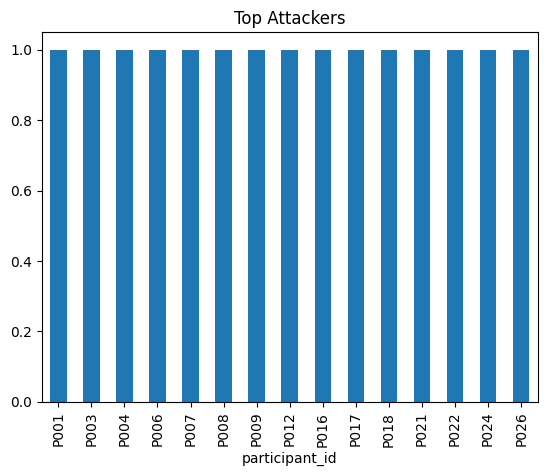

Interpretation:
Shows whether a small number of participants dominate impersonation attacks.



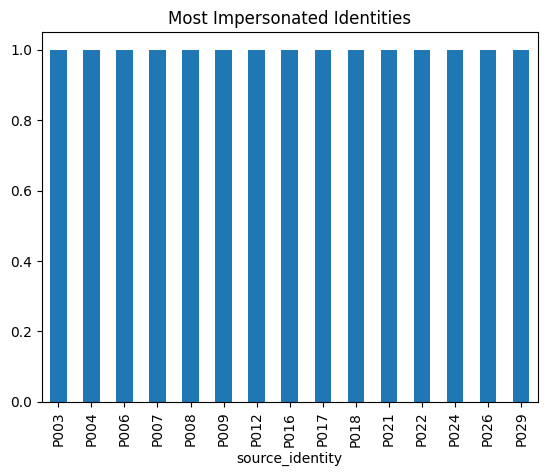

Interpretation:
Shows which identities are most frequently targeted.



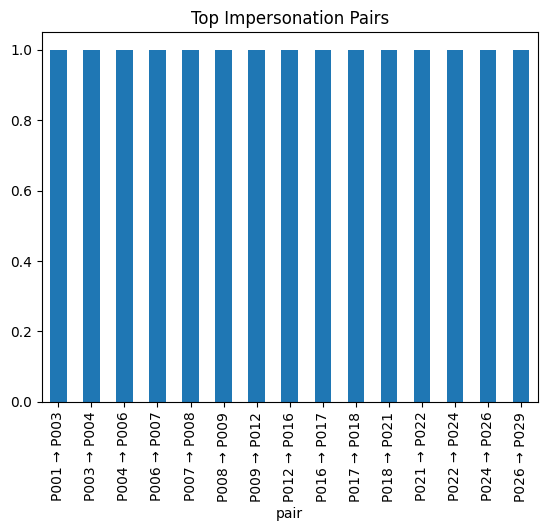

Interpretation:
Indicates whether impersonation is diverse or concentrated in a few repeated pairs.


SECTION 8: INTERPRETATION BLOCK

Identity Logic: All samples correctly represent impersonation (no identity matches).
Video Quality: All videos are readable.
Attacker Distribution: Reasonably balanced.
Pair Diversity: High diversity of impersonation pairs.

SECTION 9: FINAL ASSESSMENT
The impersonation dataset contains significant issues and requires cleaning before use.


In [3]:
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt

# =========================================================
# SECTION 1: DATASET OVERVIEW
# =========================================================

csv_path = "/content/drive/MyDrive/Final_Dataset/Sam_final_dataset/Video/impersonation_attack_metadata_fixed.csv"
df = pd.read_csv(csv_path)

print("=" * 70)
print("SECTION 1: DATASET OVERVIEW")
print("=" * 70)

print("\nDataset Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 Rows:")
display(df.head())

print("\nUnique attack types:", df["attack_type"].unique())
print("Unique labels:", df["label"].unique())

# =========================================================
# SECTION 2: INTEGRITY CHECKS
# =========================================================

print("\n" + "=" * 70)
print("SECTION 2: INTEGRITY CHECKS")
print("=" * 70)

print("\nMissing Values:")
print(df.isnull().sum())

duplicate_rows = df.duplicated().sum()
duplicate_files = df["file_path"].duplicated().sum()

print("\nDuplicate Rows:", duplicate_rows)
print("Duplicate File Paths:", duplicate_files)

invalid_attack_type = df[df["attack_type"] != "impersonation"]
invalid_label = df[df["label"] != 1]

print("\nInvalid attack_type rows:", len(invalid_attack_type))
print("Invalid label rows:", len(invalid_label))

# File existence
missing_files = []
existing_files = []

for path in df["file_path"]:
    if os.path.exists(path):
        existing_files.append(path)
    else:
        missing_files.append(path)

print("\nMissing Files:", len(missing_files))

# =========================================================
# SECTION 3: IDENTITY LOGIC VALIDATION
# =========================================================

print("\n" + "=" * 70)
print("SECTION 3: IDENTITY LOGIC VALIDATION")
print("=" * 70)

same_identity = df[df["participant_id"] == df["source_identity"]]
valid_impersonation = df[df["participant_id"] != df["source_identity"]]

print("\nSame Identity (INVALID for impersonation):", len(same_identity))
print("Valid Impersonation Samples:", len(valid_impersonation))

# =========================================================
# SECTION 4: VIDEO VALIDATION
# =========================================================

print("\n" + "=" * 70)
print("SECTION 4: VIDEO VALIDATION")
print("=" * 70)

video_stats = []
corrupted_videos = []

for path in existing_files:
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        corrupted_videos.append(path)
        continue

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    duration = frame_count / fps if fps > 0 else 0

    video_stats.append({
        "frame_count": frame_count,
        "fps": fps,
        "duration": duration
    })

    cap.release()

video_stats_df = pd.DataFrame(video_stats)

print("\nCorrupted Videos:", len(corrupted_videos))

if not video_stats_df.empty:
    print("\nDuration Summary:")
    print(video_stats_df["duration"].describe())

# =========================================================
# SECTION 5: DISTRIBUTION ANALYSIS
# =========================================================

print("\n" + "=" * 70)
print("SECTION 5: DISTRIBUTION ANALYSIS")
print("=" * 70)

# Attacker distribution
attacker_counts = df["participant_id"].value_counts()

# Target distribution
target_counts = df["source_identity"].value_counts()

print("\nTop Attackers:")
print(attacker_counts.head())

print("\nTop Target Identities:")
print(target_counts.head())

# =========================================================
# SECTION 6: PAIR ANALYSIS (IMPORTANT)
# =========================================================

print("\n" + "=" * 70)
print("SECTION 6: PAIR ANALYSIS")
print("=" * 70)

df["pair"] = df["participant_id"] + " → " + df["source_identity"]

pair_counts = df["pair"].value_counts()

print("\nUnique Impersonation Pairs:", len(pair_counts))
print("\nTop 10 Most Frequent Pairs:")
print(pair_counts.head(10))

# =========================================================
# SECTION 7: VISUALIZATIONS
# =========================================================

print("\n" + "=" * 70)
print("SECTION 7: VISUALIZATIONS")
print("=" * 70)

# Top attackers
attacker_counts.head(15).plot(kind="bar", title="Top Attackers")
plt.show()

print("Interpretation:")
print("Shows whether a small number of participants dominate impersonation attacks.\n")

# Top targets
target_counts.head(15).plot(kind="bar", title="Most Impersonated Identities")
plt.show()

print("Interpretation:")
print("Shows which identities are most frequently targeted.\n")

# Pair distribution
pair_counts.head(15).plot(kind="bar", title="Top Impersonation Pairs")
plt.show()

print("Interpretation:")
print("Indicates whether impersonation is diverse or concentrated in a few repeated pairs.\n")

# =========================================================
# SECTION 8: INTERPRETATION BLOCK
# =========================================================

print("\n" + "=" * 70)
print("SECTION 8: INTERPRETATION BLOCK")
print("=" * 70)

if len(same_identity) == 0:
    print("\nIdentity Logic: All samples correctly represent impersonation (no identity matches).")
else:
    print("\nIdentity Logic: Some samples violate impersonation rules (participant == source_identity).")

if len(corrupted_videos) == 0:
    print("Video Quality: All videos are readable.")
else:
    print("Video Quality: Some videos are corrupted or unreadable.")

if attacker_counts.max() <= 3 * attacker_counts.mean():
    print("Attacker Distribution: Reasonably balanced.")
else:
    print("Attacker Distribution: Imbalance detected.")

if len(pair_counts) > len(df) * 0.5:
    print("Pair Diversity: High diversity of impersonation pairs.")
else:
    print("Pair Diversity: Limited diversity, repeated impersonations detected.")

# =========================================================
# SECTION 9: FINAL ASSESSMENT
# =========================================================

print("\n" + "=" * 70)
print("SECTION 9: FINAL ASSESSMENT")
print("=" * 70)

critical_issues = (
    len(invalid_attack_type) +
    len(invalid_label) +
    len(same_identity) +
    len(missing_files) +
    len(corrupted_videos)
)

if critical_issues == 0:
    print("The impersonation dataset is valid, correctly structured, and suitable for evaluating identity-based spoof attacks.")
elif critical_issues < 5:
    print("The impersonation dataset is mostly usable but contains minor issues that should be cleaned.")
else:
    print("The impersonation dataset contains significant issues and requires cleaning before use.")